#**Smriddhi Gupta**

84530018

B.Sc. Digital Business and Data Science

(Semester 2)


# **“IM WALD” – Analysis and Communication**

In [ ]:
# 3 research questions
# 1) If the trend in the plot continues, which country might face the most severe deforestation impact in the next decade?
# 2) Which country experienced the most fluctuation in tree cover loss between 2000 and 2020?
# 3) How does tree cover loss in European regions like Portugal , Italy and Greece compared to regions like South Africa and Australia?

In [ ]:
# Connect to google drive to import file
from google.colab import drive
# Logging to google account and confirm connection
drive.mount('/drive')

Mounted at /drive


In [ ]:
# Checking the drive
!ls /drive/MyDrive/IM_Wald_Assignment/

'Smriddhi Gupta Im Wald Assignment.pynb'  'Tree Cover Loss.csv'


In [ ]:
# Reading the content in the csv file
with open('/drive/MyDrive/IM_Wald_Assignment/Tree Cover Loss.csv', 'r') as f:
  b = f.read()
print(b)

Entity,Code,Year,Total tree cover loss
Afghanistan,AFG,2001,88.09271
Africa,AFR,2001,1390070.4
Akrotiri and Dhekelia,OWID_AKD,2001,1.6489892
Aland Islands,ALA,2001,396.9348
Albania,ALB,2001,3729.021
Algeria,DZA,2001,3468.7603
Andorra,AND,2001,1.654213
Angola,AGO,2001,101220.62
Anguilla,AIA,2001,3.8784606
Antigua and Barbuda,ATG,2001,24.07419
Argentina,ARG,2001,147805.95
Armenia,ARM,2001,131.8406
Asia,,2001,1704670.9
Australia,AUS,2001,218816.31
Austria,AUT,2001,6926.269
Azerbaijan,AZE,2001,553.2994
Bahamas,BHS,2001,432.99945
Bangladesh,BGD,2001,4586.9976
Barbados,BRB,2001,12.367462
Belarus,BLR,2001,18358.965
Belgium,BEL,2001,971.48816
Belize,BLZ,2001,8211.63
Benin,BEN,2001,3749.331
Bermuda,BMU,2001,0.1958198
Bhutan,BTN,2001,297.65964
Bolivia,BOL,2001,140321.25
Bonaire Sint Eustatius and Saba,BES,2001,3.0318573
Bosnia and Herzegovina,BIH,2001,1496.1072
Botswana,BWA,2001,130.98389
Brazil,BRA,2001,2746361.5
British Virgin Islands,VGB,2001,4.092501
Brunei,BRN,2001,1244.4537
Bulgaria,BGR,20

In [ ]:
# Importing the libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Loading csv into dataframe
df = pd.read_csv('/drive/MyDrive/IM_Wald_Assignment/Tree Cover Loss.csv')

# Printing it in different columns
print(df)

                     Entity      Code  Year  Total tree cover loss
0               Afghanistan       AFG  2001           8.809271e+01
1                    Africa       AFR  2001           1.390070e+06
2     Akrotiri and Dhekelia  OWID_AKD  2001           1.648989e+00
3             Aland Islands       ALA  2001           3.969348e+02
4                   Albania       ALB  2001           3.729021e+03
...                     ...       ...   ...                    ...
4799              Venezuela       VEN  2023           7.661421e+04
4800                Vietnam       VNM  2023           1.353156e+05
4801                  World  OWID_WRL  2023           2.825607e+07
4802                 Zambia       ZMB  2023           1.904166e+05
4803               Zimbabwe       ZWE  2023           5.690372e+03

[4804 rows x 4 columns]


In [ ]:
# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
              Year  Total tree cover loss
count  4804.000000           4.804000e+03
mean   2011.860533           4.060733e+05
std       6.624150           1.869292e+06
min    2001.000000           0.000000e+00
25%    2006.000000           1.074236e+02
50%    2012.000000           4.824535e+03
75%    2018.000000           5.922284e+04
max    2023.000000           2.967478e+07


###**"If the trend in the plot continues, which country might face the most severe deforestation impact in the next decade?"**

<ipython-input-8-37199ff417d6>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "Total tree cover loss", y = "Entity", data = data_2020, palette = custom_colors)


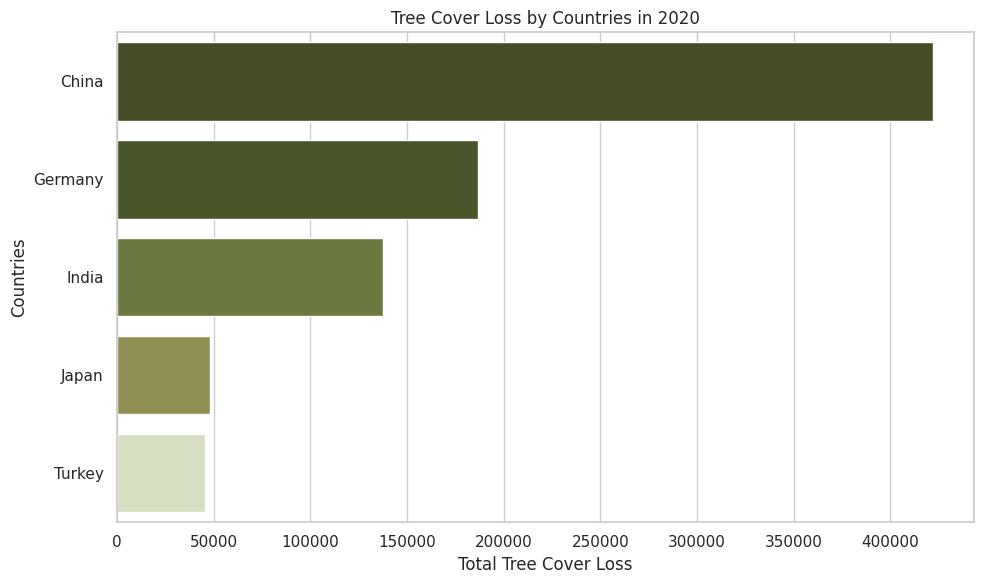

In [ ]:
# List of continents
countries = ["China", "Germany", "India", "Japan", "Turkey"]
# Filtering the data for the countries and the year 2020
data_2020 = df[(df["Entity"].isin(countries)) & (df["Year"] == 2020)]
# Gives customized colors to the plot
custom_colors = ["#4B5320", "#4A5D23", "#708238", "#9B9A4A", "#D8E4BC"]

# Sets the overall style for the plots (white grid background)
sns.set_theme(style="whitegrid")
# Sets the figure size (width = 10 inches, height = 6 inches)
plt.figure(figsize=(10, 6))

# Create a horizontal barplot using seaborn
# x => x-axis: Total tree cover loss values
# y => y-axis: Country names (Entity)
# Extraction data from particularly year 2020
# palette: custom_colors is a predefined list of hex color codes or named colors
sns.barplot(x = "Total tree cover loss", y = "Entity", data = data_2020, palette = custom_colors)

# Adds a title to the plot
plt.title("Tree Cover Loss by Countries in 2020")
# Labels the x-axis
plt.xlabel("Total Tree Cover Loss")
# Labels the y-axis
plt.ylabel("Countries")
# Automatically adjust subplot params so the plot fits in the figure area neatly
plt.tight_layout()
# Displays the final plot
plt.show()



###**"Which country experienced the most fluctuation in tree cover loss between 2000 and 2020?"**

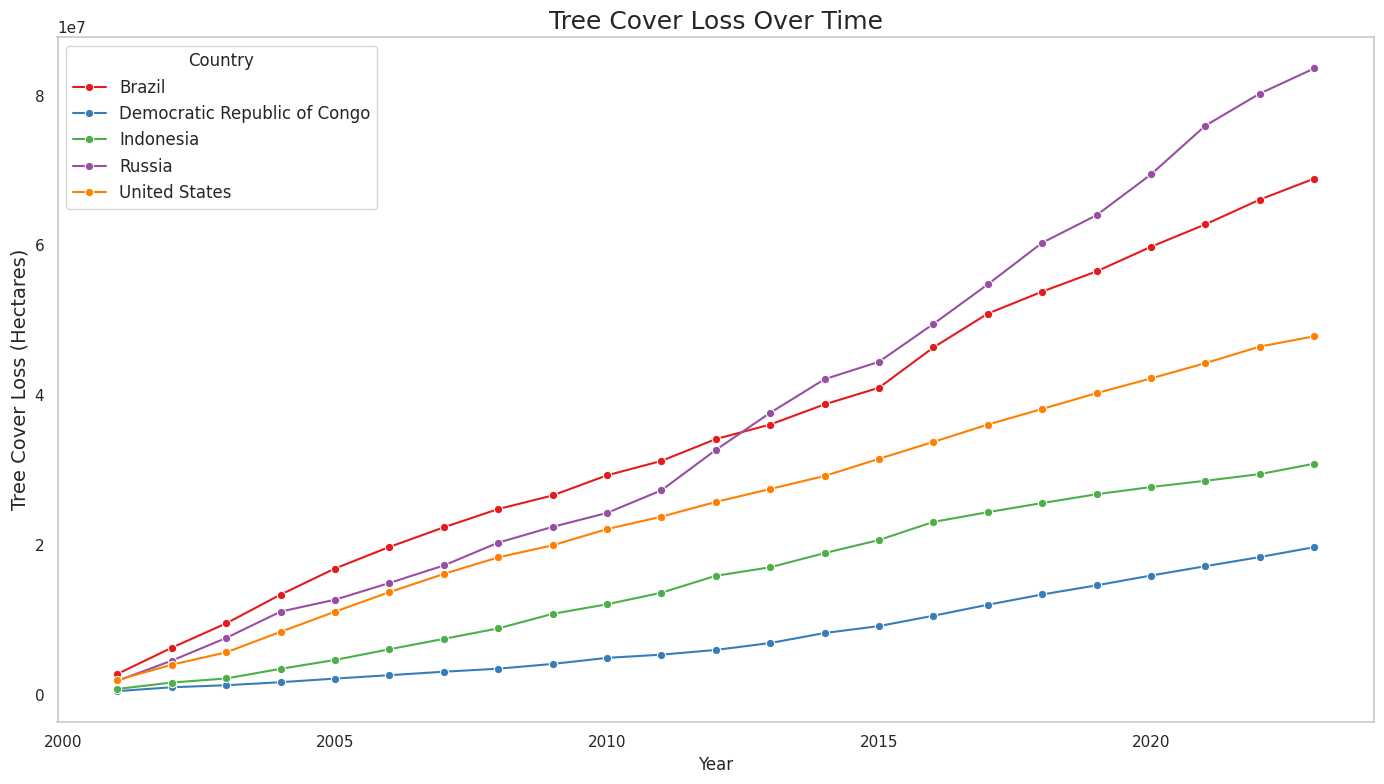

In [ ]:
# Defines a list of countries to analyze
countries_selected = ['Brazil', 'Indonesia', 'Democratic Republic of Congo', 'United States', 'Russia']
# Filters the original data frame to only include the selected countries
tree_loss = df[df['Entity'].isin(countries_selected)].copy()
# Sorts the filtered data by country and year for correct cumulative sum calculation
tree_loss.sort_values(by = ['Entity', 'Year'], inplace = True)

# Compute the cumulative tree cover loss for each country
# This shows how tree loss accumulates over time
tree_loss['Loss'] = tree_loss.groupby('Entity')['Total tree cover loss'].cumsum()

# Sets the plot size
plt.figure(figsize = (14, 8))
# Creates a line plot showing cumulative tree loss over time, one line per country
sns.lineplot(data = tree_loss, x = "Year", y = "Loss", hue = "Entity", marker = "o", palette = "Set1")
# Title and give font size
plt.title("Tree Cover Loss Over Time", fontsize = 18)
# Titles x-axis
plt.xlabel("Year")
# Titles y-axis with font size
plt.ylabel("Tree Cover Loss (Hectares)", fontsize = 14)
# Improves legend appearance
plt.legend(title = 'Country', fontsize = 12)
plt.grid(False)
# Adjusts spacing
plt.tight_layout()
# Displays the final plot
plt.show()


###**"How does tree cover loss in European regions like Portugal , Italy and Greece compared to regions like South Africa and Australia?"**

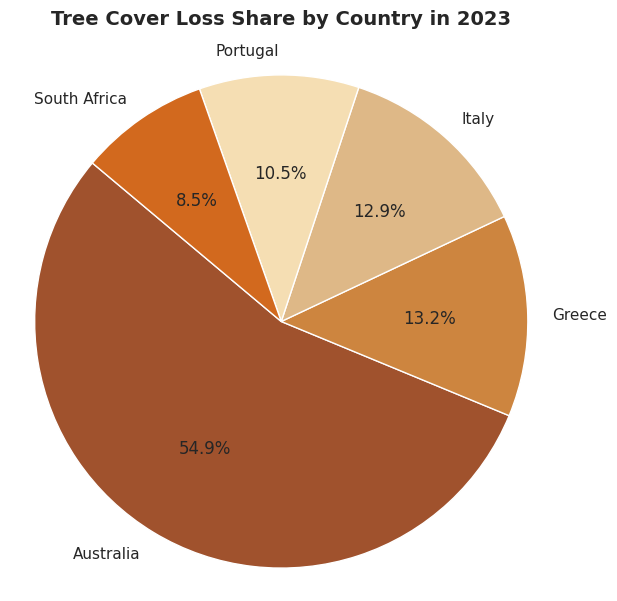

In [ ]:
# List of selected countries
c = ['Australia', 'South Africa', 'Italy', 'Greece', 'Portugal']
# Filters dataset for the year 2023
data_2023 = df[(df["Entity"].isin(c)) & (df["Year"] == 2023)]
# Extract values for pie chart
values = data_2023["Total tree cover loss"]
labels = data_2023["Entity"]
# ECustomized colors for the pie chart
custom_color = ['#A0522D', '#CD853F', '#DEB887', '#F5DEB3', '#D2691E', '#BC8F8F']

# Create pie chart
plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=140, colors=sns.color_palette(custom_color))
# Underlined and padded title
plt.title("Tree Cover Loss Share by Country in 2023", fontsize=14, fontweight='bold', pad=20)
# Making sure pie is a circle
plt.axis("equal")
# Displays the final chart
plt.show()
